In [ ]:
"""Three-regime HMM on S&P 500 daily returns, fitted with hmmlearn.

Ported from notebooks/test.ipynb: the local flexible_emission_hmm package is
replaced by hmmlearn's GaussianHMM, state count raised from 2 to 3, and model
selection uses the AIC/BIC computed by the HMM itself (hmmlearn >= 0.3).
Note: hmmlearn's score() is the *total* sequence log-likelihood, so divide by
len(X) for per-day numbers; aic()/bic() are computed on the total.
"""

import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

project_root = Path(__file__).resolve().parents[1]
DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
MAX_ITER, TOL, MIN_COVAR = 120, 1e-3, 1e-5   # MIN_COVAR mirrors MIN_VARIANCE
N_STATES = 3
VOLATILITY_DAYS, MOMENTUM_DAYS = 60, 20
N_RESTARTS = 10   # Baum-Welch is non-convex: keep the best likelihood

In [ ]:
data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"]
returns = np.log(prices).diff().dropna().rename("r_t")

training = returns.loc["1988":"1997"]     # 10 training years, 1998 excluded
validation = returns.loc["1998":"1999"]   # avoid 2000 for now
test = returns.loc["2001"]

if any(series.empty for series in (validation, training, test)):
    raise ValueError("A requested period is empty")
if len(training.index.year.unique()) != 10 or test.index.year.unique().tolist() != [2001]:
    raise ValueError("Expected ten training years and 2001 evaluation")

In [ ]:
# --- features: r_t, sigma_t, m_t (replaces flexible_emission_hmm.compute_features)
transformed = pd.concat(
    [
        returns.rename("r_t"),
        returns.rolling(VOLATILITY_DAYS, min_periods=VOLATILITY_DAYS)
        .std(ddof=1)
        .rename("sigma_t"),
        returns.rolling(MOMENTUM_DAYS, min_periods=MOMENTUM_DAYS)
        .mean()
        .rename("m_t"),
    ],
    axis=1,
)

transformed_train = transformed.loc[training.index]
transformed_val = transformed.loc[validation.index]
transformed_test = transformed.loc[test.index]

print(f"Validation: {len(validation)} days")
print(f"Full training: {len(training)} days; held-out 2001: {len(test)} days")

Validation: 504 days
Full training: 2529 days; held-out 2001: 248 days


In [ ]:
logging.getLogger("hmmlearn").setLevel(logging.ERROR)  # drop per-restart noise

In [ ]:
def fit_hmmlearn(X: np.ndarray, n_states: int) -> GaussianHMM:
    """Fit with N_RESTARTS seeds and keep the highest-likelihood model.

    Restarts where EM starves a state produce NaN parameters in hmmlearn
    (0/0 in the M-step); score() then raises, so those seeds are skipped.
    """
    best, best_score = None, -np.inf
    for seed in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            min_covar=MIN_COVAR,
            n_iter=MAX_ITER,
            tol=TOL,
            random_state=seed,
        )
        try:
            model.fit(X)
            score = model.score(X)
        except ValueError:  # NaN/inf parameters from a collapsed state
            continue
        if np.isfinite(score) and score > best_score:
            best, best_score = model, score
    if best is None:
        raise RuntimeError(f"All {N_RESTARTS} restarts collapsed for n_states={n_states}")
    return best


X_train = transformed_train.to_numpy()   # (T, 3): r_t, sigma_t, m_t
model = fit_hmmlearn(X_train, N_STATES)

fitted = pd.DataFrame(
    {
        "mean_r": model.means_[:, 0],
        "sd_r": np.sqrt(model.covars_[:, 0, 0]),
        "mean_sigma": model.means_[:, 1],
    }
)
high_state = int(fitted["sd_r"].idxmax())  # state with the fatter return distribution
print(fitted.round(4))
print(np.round(model.transmat_, 3))
print(
    f"converged={model.monitor_.converged} "
    f"in {len(model.monitor_.history) - 1} EM iterations"
)

# --- model selection: AIC / BIC from the HMM itself (lower is better)
selection = []
for k in (2, N_STATES):
    fitted_k = fit_hmmlearn(X_train, k)
    n_params = sum(fitted_k._get_n_fit_scalars_per_param().values())
    selection.append(
        {
            "n_states": k,
            "logL/day (train)": fitted_k.score(X_train) / len(X_train),
            "n_params": n_params,
            "AIC (train)": fitted_k.aic(X_train),
            "BIC (train)": fitted_k.bic(X_train),
        }
    )
selection = pd.DataFrame(selection).set_index("n_states")
print(selection.round(3))

/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


   mean_r    sd_r  mean_sigma
0 -0.0001  0.0108      0.0104
1  0.0008  0.0070      0.0067
2 -0.0000  0.0205      0.0174
[[0.964 0.026 0.011]
 [0.007 0.992 0.001]
 [0.062 0.    0.938]]
converged=True in 15 EM iterations


/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


          logL/day (train)  n_params  AIC (train)  BIC (train)
n_states                                                      
2                   12.962        21   -65517.471   -65394.924
3                   13.099        35   -66183.838   -65979.592


       HMM NLL/day  Gaussian NLL/day
split                               
train    -13.09882          -3.37706
val      -12.10265          -2.80612
test     -11.26851          -2.52278


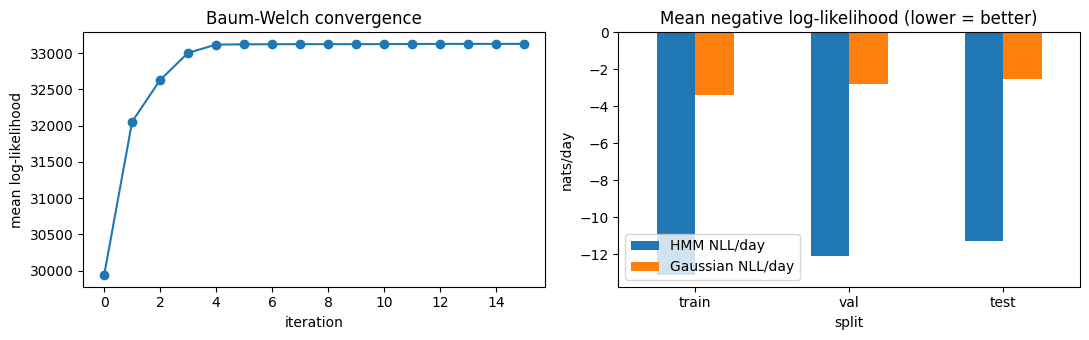

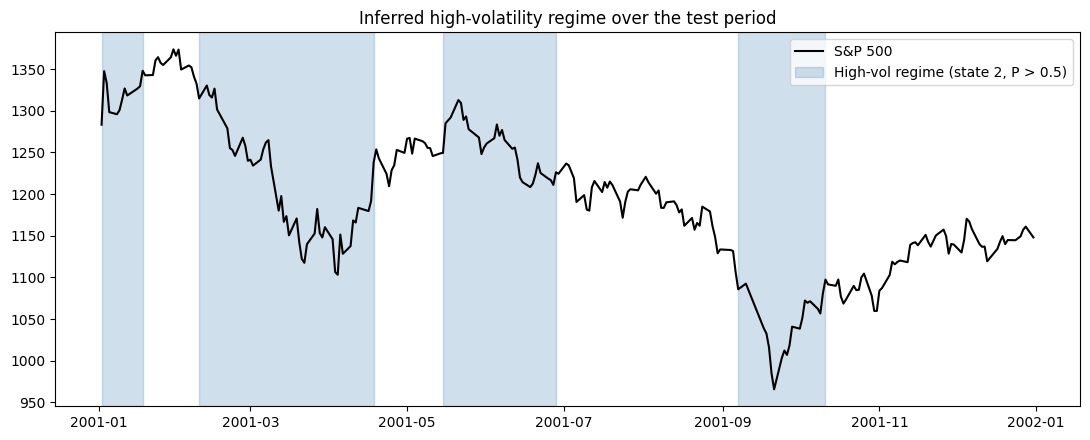

In [ ]:
# --- held-out likelihood vs an iid-Gaussian baseline fitted on train only
rows = []
mu0, sd0 = training.mean(), training.std(ddof=1)
for name, split in [("train", training), ("val", validation), ("test", test)]:
    X = transformed.loc[split.index].to_numpy()
    hmm_nll = -model.score(X) / len(X)  # score() is total log-likelihood
    gauss_nll = (
        0.5 * np.log(2 * np.pi * sd0**2) + 0.5 * ((split - mu0) / sd0) ** 2
    ).mean()
    rows.append({"split": name, "HMM NLL/day": hmm_nll, "Gaussian NLL/day": gauss_nll})
metrics = pd.DataFrame(rows).set_index("split")
print(metrics.round(5))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(model.monitor_.history, marker="o")
axes[0].set(
    title="Baum-Welch convergence", xlabel="iteration", ylabel="mean log-likelihood"
)
metrics.plot.bar(ax=axes[1], rot=0)
axes[1].set(title="Mean negative log-likelihood (lower = better)", ylabel="nats/day")
fig.tight_layout()

# --- regime shading over the test period
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(prices.loc[test.index], color="black", label="S&P 500")
proba = model.predict_proba(transformed_test.to_numpy())[:, high_state]
ax.fill_between(
    test.index,
    0,
    1,
    where=proba > 0.5,
    transform=ax.get_xaxis_transform(),
    color="steelblue",
    alpha=0.25,
    label=f"High-vol regime (state {high_state}, P > 0.5)",
)
ax.legend()
ax.set(title="Inferred high-volatility regime over the test period")
fig.tight_layout()